In [11]:
# Install required library
!pip install tf_keras gdown -q

# Download pre-trained weights from DeepWeeds repository
!gdown 1MRbN5hXOTYnw7-71K-2vjY01uJ9GkQM5 -O /content/models.zip
!unzip -q /content/models.zip -d /content/models
!ls /content/models

Downloading...
From (original): https://drive.google.com/uc?id=1MRbN5hXOTYnw7-71K-2vjY01uJ9GkQM5
From (redirected): https://drive.google.com/uc?id=1MRbN5hXOTYnw7-71K-2vjY01uJ9GkQM5&confirm=t&uuid=148a3123-a764-4f9b-9796-fb31baa54fdd
To: /content/models.zip
100% 501M/501M [00:03<00:00, 156MB/s]
replace /content/models/inception.hdf5? [y]es, [n]o, [A]ll, [N]one, [r]ename: inception.hdf5	resnet.hdf5


In [12]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tf_keras as keras
from tf_keras import layers, models
from tf_keras.preprocessing.image import ImageDataGenerator
from tf_keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


In [ ]:
# Import google drive
from google.colab import drive
# Mount Google Drive to access files and datasets inside Colab
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Create datasets directory if it does not exist
!mkdir -p /content/mask_dataset

# Extract the mask dataset into the datasets folder
!unzip -q "/content/drive/MyDrive/Face mask dataSet.zip" -d /content/mask_dataset

# List extracted dataset files
!ls "/content/mask_dataset/Face Mask Dataset"

Test  Train  Validation


In [19]:
# Parameters
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 50
SAMPLE_SIZE   = 2000
LEARNING_RATE = 0.001

# Dataset paths
train_path      = "/content/mask_dataset/Face Mask Dataset/Train"
val_path        = "/content/mask_dataset/Face Mask Dataset/Validation"
test_path       = "/content/mask_dataset/Face Mask Dataset/Test"
sample_train_path = "/content/sample_train"

classes = os.listdir(train_path)

# Delete old sample if exists
import shutil
if os.path.exists(sample_train_path):
    shutil.rmtree(sample_train_path)
    print("Old sample deleted!")

# Randomly sample images from each class
for cls in classes:
    os.makedirs(os.path.join(sample_train_path, cls), exist_ok=True)
    class_path = os.path.join(train_path, cls)
    images     = os.listdir(class_path)
    sampled    = random.sample(images, SAMPLE_SIZE)
    for img in sampled:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(sample_train_path, cls, img)
        )

print(f"Done! {SAMPLE_SIZE} images per class = {SAMPLE_SIZE * len(classes)} total")


Old sample deleted!
Done! 2000 images per class = 4000 total


In [21]:
# Load and preprocess data

datagen = ImageDataGenerator(rescale=1./255)

# Training data — using sampled dataset
train_data = datagen.flow_from_directory(
    sample_train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Validation data — full validation set
val_data = datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Test data — full test set, no shuffling for evaluation
test_data = datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass indices: {train_data.class_indices}")

Found 4000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.

Class indices: {'WithMask': 0, 'WithoutMask': 1}


In [22]:
# Load DeepWeeds pre-trained ResNet50 weights
# Load without compiling to avoid optimizer compatibility issues
model = keras.models.load_model(
    '/content/models/resnet.hdf5',
    compile=False
)

print("Model loaded!")
print(f"Original output shape: {model.output_shape}")

Model loaded!
Original output shape: (None, 9)


In [24]:
# Modify model for Face Mask Detection
# Freeze all layers
for layer in model.layers:
    layer.trainable = False

# Replace final layer
x = model.layers[-2].output
output = layers.Dense(2, activation='softmax', name='fc_mask')(x)

# Build new model
new_model = keras.Model(inputs=model.input, outputs=output)

# Compile
new_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    '/content/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train
history = new_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stopping, model_checkpoint]
)

# Results
test_loss, test_acc = new_model.evaluate(test_data, verbose=0)
print(f"\nSample: {SAMPLE_SIZE} | Epochs: {EPOCHS}")
print(f"Test Accuracy: {test_acc:.2%}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Learning Rate: {new_model.optimizer.learning_rate.numpy()}")

Epoch 1/50
125/125 [==============================] - ETA: 0s - loss: 0.0130 - accuracy: 0.9983
Epoch 1: val_accuracy improved from -inf to 0.98375, saving model to /content/best_model.keras
125/125 [==============================] - 26s 209ms/step - loss: 0.0130 - accuracy: 0.9983 - val_loss: 0.0498 - val_accuracy: 0.9837
Epoch 2/50
125/125 [==============================] - ETA: 0s - loss: 0.0113 - accuracy: 0.9977
Epoch 2: val_accuracy improved from 0.98375 to 0.98750, saving model to /content/best_model.keras
125/125 [==============================] - 19s 154ms/step - loss: 0.0113 - accuracy: 0.9977 - val_loss: 0.0356 - val_accuracy: 0.9875
Epoch 3/50
125/125 [==============================] - ETA: 0s - loss: 0.0103 - accuracy: 0.9990
Epoch 3: val_accuracy did not improve from 0.98750
125/125 [==============================] - 18s 145ms/step - loss: 0.0103 - accuracy: 0.9990 - val_loss: 0.0307 - val_accuracy: 0.9875
Epoch 4/50
125/125 [==============================] - ETA: 0s - lo

31/31 [==============================] - 4s 134ms/step
Classification Report
              precision    recall  f1-score   support

   With Mask       0.99      0.99      0.99       483
Without Mask       0.99      0.99      0.99       509

    accuracy                           0.99       992
   macro avg       0.99      0.99      0.99       992
weighted avg       0.99      0.99      0.99       992



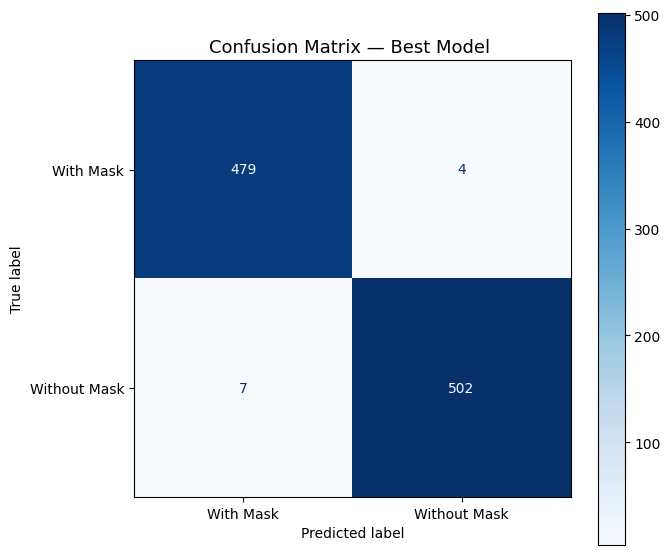

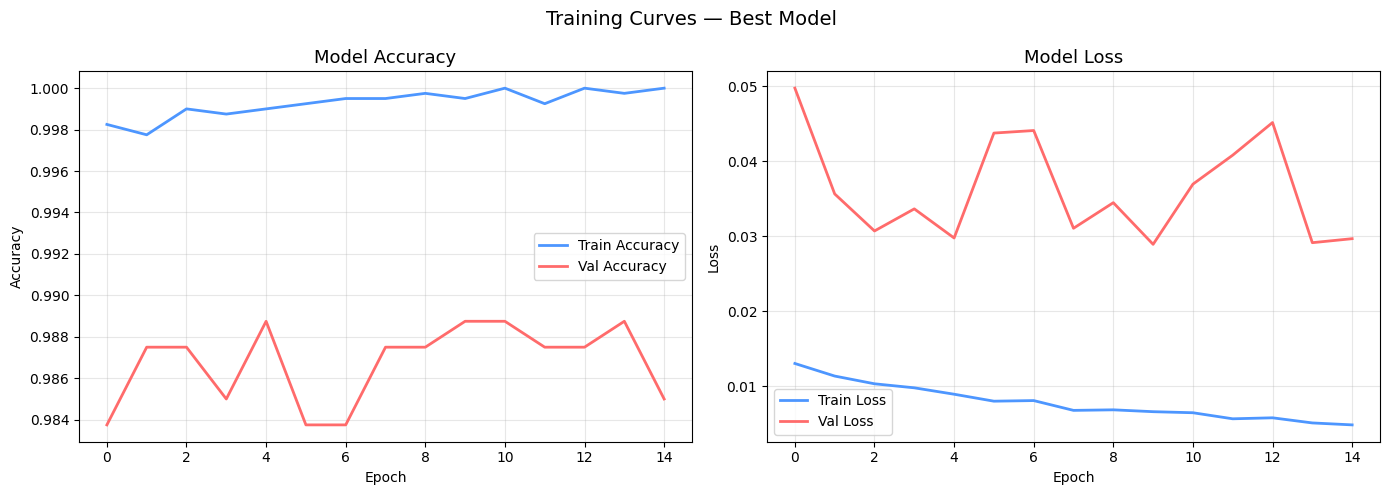

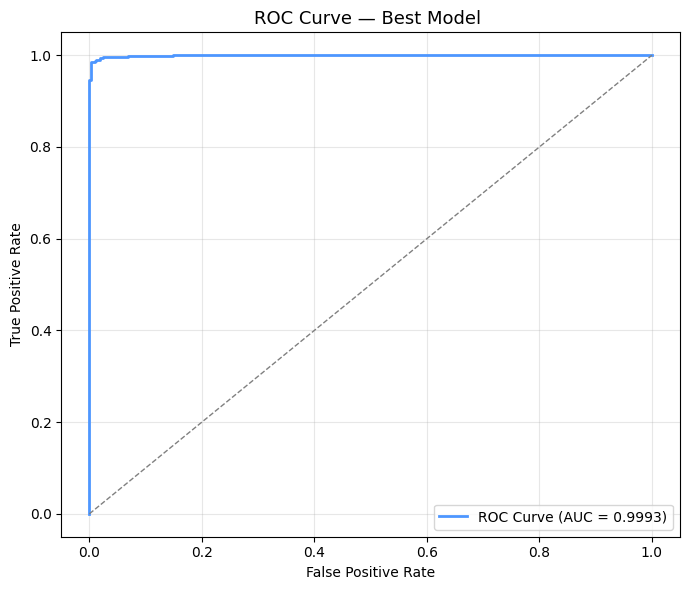

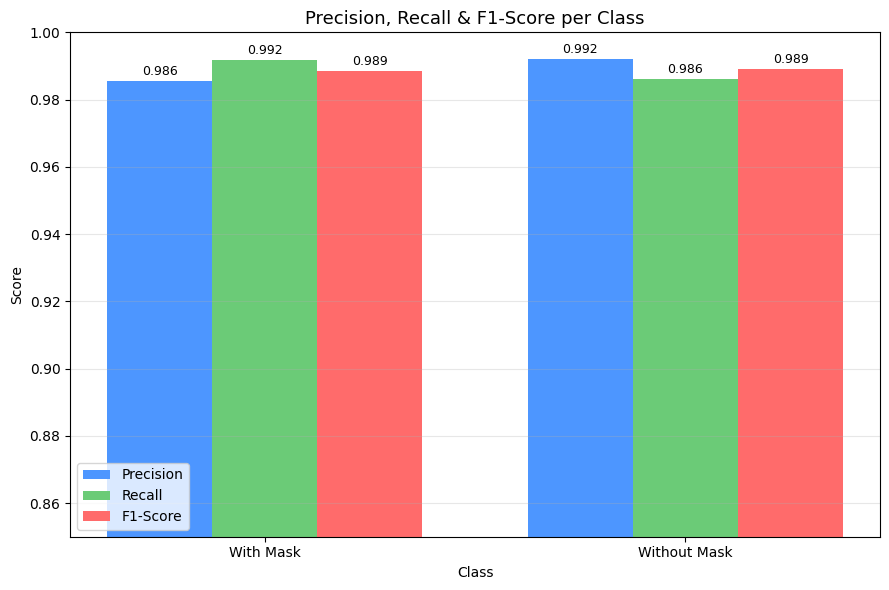


Final Results — Best Model 
Sample Size:    2000
Epochs:         50
Test Accuracy:  98.89%
Test Loss:      0.0312
AUC:            0.9993
F1-Score (W):   0.9889
Precision (W):  0.9889
Recall (W):     0.9889


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, f1_score,
                              precision_score, recall_score, roc_curve, auc)


# 1. Predictions

y_pred_probs = new_model.predict(test_data, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_data.classes
class_names = ['With Mask', 'Without Mask']


# 2. Classification Report

print("=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))


# 3. Confusion Matrix


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(7, 6))
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix — Best Model ', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()


# 4. Training Curves (Accuracy & Loss)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='#4d96ff', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='#ff6b6b', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss', color='#4d96ff', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss',   color='#ff6b6b', linewidth=2)
ax2.set_title('Model Loss', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training Curves — Best Model ', fontsize=14)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()


# 5. ROC Curve


fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#4d96ff', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
plt.title('ROC Curve — Best Model ', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curve.png', dpi=150)
plt.show()


# 6. Metrics Bar Chart (Precision, Recall, F1)


precision = precision_score(y_true, y_pred, average=None)
recall    = recall_score(y_true, y_pred, average=None)
f1        = f1_score(y_true, y_pred, average=None)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width, precision, width, label='Precision', color='#4d96ff')
ax.bar(x,         recall,    width, label='Recall',    color='#6bcb77')
ax.bar(x + width, f1,        width, label='F1-Score',  color='#ff6b6b')

ax.set_title('Precision, Recall & F1-Score per Class', fontsize=13)
ax.set_xlabel('Class')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0.85, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=9)

plt.tight_layout()
plt.savefig('/content/metrics_chart.png', dpi=150)
plt.show()


# 7. Final Summary

test_loss, test_acc = new_model.evaluate(test_data, verbose=0)

print("\n" + "=" * 50)
print("Final Results — Best Model ")
print("=" * 50)
print(f"Sample Size:    2000")
print(f"Epochs:         50")
print(f"Test Accuracy:  {test_acc:.2%}")
print(f"Test Loss:      {test_loss:.4f}")
print(f"AUC:            {roc_auc:.4f}")
print(f"F1-Score (W):   {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Precision (W):  {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall (W):     {recall_score(y_true, y_pred, average='weighted'):.4f}")
print("=" * 50)

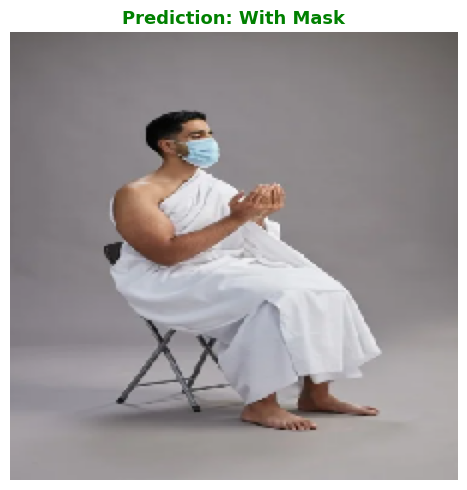

Result: With Mask


In [40]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_mask(img_path):

    # Load and resize image to 224x224
    img = image.load_img(img_path, target_size=(224, 224))

    # Convert image to array and normalize pixels to 0-1
    img_array = image.img_to_array(img) / 255.0

    # Add batch dimension (model expects 4D input)
    img_array = np.expand_dims(img_array, axis=0)

    # Get model prediction
    prediction = new_model.predict(img_array, verbose=0)

    # Get class with highest probability
    class_idx = np.argmax(prediction)

    # Class labels
    class_names = ['With Mask', 'Without Mask']
    result = class_names[class_idx]

    # Display image with prediction
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f'Prediction: {result}',
              fontsize=13,
              fontweight='bold',
              color='green' if class_idx == 0 else 'red')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Result: {result}")

# Change path to your image
predict_mask('/content/test .png')

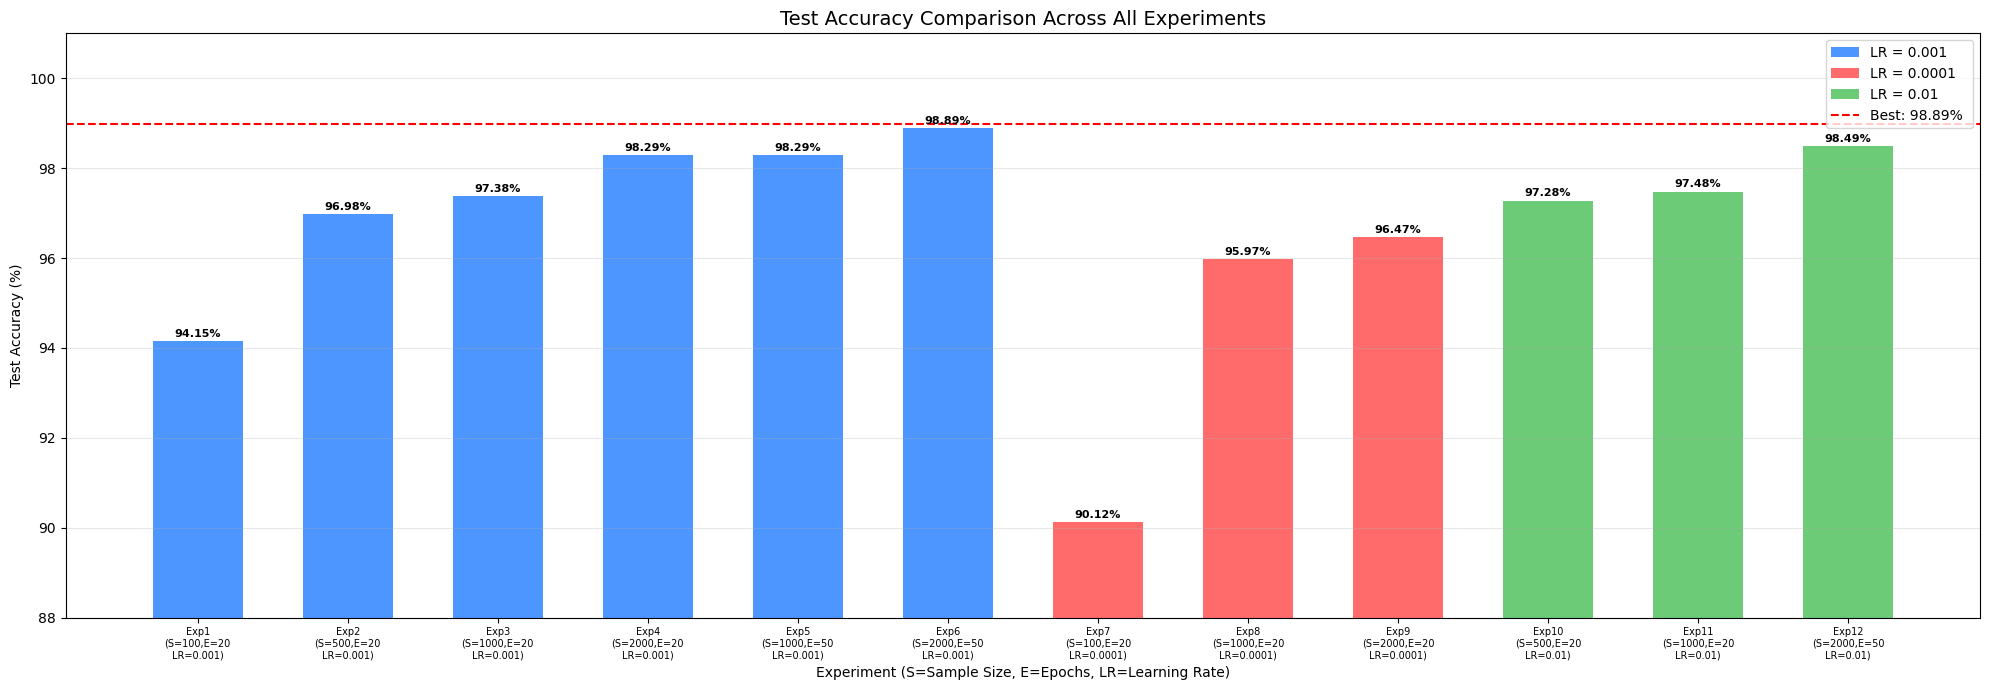

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Experiment labels
experiments = [
    'Exp1\n(S=100,E=20\nLR=0.001)',
    'Exp2\n(S=500,E=20\nLR=0.001)',
    'Exp3\n(S=1000,E=20\nLR=0.001)',
    'Exp4\n(S=2000,E=20\nLR=0.001)',
    'Exp5\n(S=1000,E=50\nLR=0.001)',
    'Exp6\n(S=2000,E=50\nLR=0.001)',
    'Exp7\n(S=100,E=20\nLR=0.0001)',
    'Exp8\n(S=1000,E=20\nLR=0.0001)',
    'Exp9\n(S=2000,E=20\nLR=0.0001)',
    'Exp10\n(S=500,E=20\nLR=0.01)',
    'Exp11\n(S=1000,E=20\nLR=0.01)',
    'Exp12\n(S=2000,E=50\nLR=0.01)',
]

test_accs = [94.15, 96.98, 97.38, 98.29, 98.29, 98.89,
             90.12, 95.97, 96.47, 97.28, 97.48, 98.49]

# Colors grouped by LR
colors = [
    '#4d96ff','#4d96ff','#4d96ff','#4d96ff','#4d96ff','#4d96ff',  # LR=0.001
    '#ff6b6b','#ff6b6b','#ff6b6b',                                  # LR=0.0001
    '#6bcb77','#6bcb77','#6bcb77'                                    # LR=0.01
]

plt.figure(figsize=(20, 7))
bars = plt.bar(experiments, test_accs, color=colors, width=0.6)

# Values on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{bar.get_height():.2f}%',
             ha='center', va='bottom',
             fontweight='bold', fontsize=8)

# Best result line
plt.axhline(y=98.99, color='red', linestyle='--',
            linewidth=1.5, label='Best: 98.89% ')

# Legend for LR colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4d96ff', label='LR = 0.001'),
    Patch(facecolor='#ff6b6b', label='LR = 0.0001'),
    Patch(facecolor='#6bcb77', label='LR = 0.01'),
]
plt.legend(handles=legend_elements + [plt.Line2D([0], [0], color='red',
           linestyle='--', label='Best: 98.89% ')],
           fontsize=10)

plt.title('Test Accuracy Comparison Across All Experiments', fontsize=14)
plt.xlabel('Experiment (S=Sample Size, E=Epochs, LR=Learning Rate)')
plt.ylabel('Test Accuracy (%)')
plt.ylim(88, 101)
plt.grid(axis='y', alpha=0.3)
plt.xticks(fontsize=7)
plt.tight_layout()
plt.savefig('/content/comparison_chart.png', dpi=150)
plt.show()